# Chapter 171 — Eigenvalue Computation

> **Prerequisites:** ch170 (Eigenvalues Intuition), ch161 (Gaussian Elimination), ch163 (LU Decomposition)
> **You will learn:**
> - Why direct polynomial root-finding fails for large matrices
> - Power iteration and its convergence properties
> - The QR algorithm — the practical workhorse for eigenvalue computation
> - How to interpret numerical eigenvalue output reliably
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Computing eigenvalues is not as simple as solving the characteristic polynomial. For n > 4, no closed-form formula exists (Abel-Ruffini theorem). Numerical algorithms are required.

Three practical algorithms:

1. **Power iteration** — finds the single largest eigenvalue. Simple, interpretable, but limited.
2. **Inverse iteration** — finds the eigenvalue closest to a target. Useful for specific eigenvalues.
3. **QR algorithm** — finds ALL eigenvalues simultaneously. This is what `numpy.linalg.eig` uses under the hood.

**Common misconception:** `np.linalg.eig` gives exact eigenvalues. It does not — it gives floating-point approximations. For ill-conditioned matrices, these can be far from the true values.

## 2. Intuition & Mental Models

**Power iteration intuition:** Start with a random vector. Apply A repeatedly and normalize. The component along the dominant eigenvector grows fastest (eigenvalue > others), so after enough steps, only that component survives. Recall this idea from ch169's mini project.

**QR algorithm intuition:** The QR algorithm decomposes A = QR, then forms A' = RQ (a *similarity transformation* — same eigenvalues, different basis). Repeating this process causes the matrix to converge toward an upper triangular form. The eigenvalues appear on the diagonal.

**Computational:** Think of the QR algorithm as "rotating the matrix into its own eigenspace." Each iteration rotates the coordinate system slightly toward the eigenvector basis. The convergence is typically quadratic (doubles significant digits per iteration).

## 3. Visualization

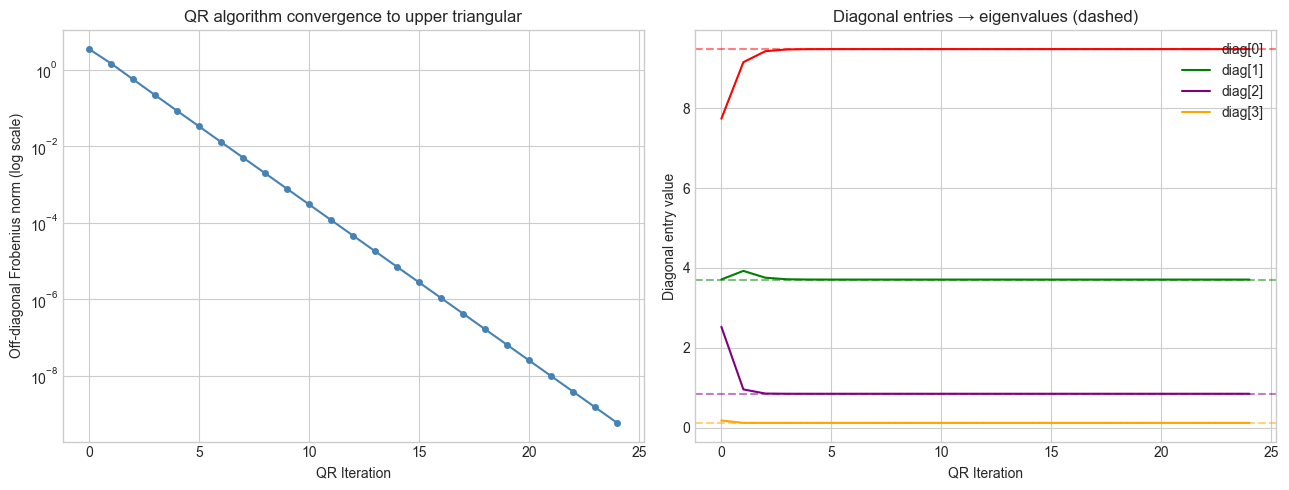

In [1]:
# --- Visualization: QR iteration converging to upper triangular ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
# Symmetric matrix for clean real eigenvalues
M = np.random.randn(4, 4)
A = M @ M.T  # positive definite symmetric

N_ITER = 25
off_diag_norms = []  # measure how "upper triangular" matrix becomes
diagonals = []       # track diagonal entries

Ak = A.copy()
for _ in range(N_ITER):
    Q, R = np.linalg.qr(Ak)
    Ak = R @ Q  # similarity transform: same eigenvalues
    # Off-diagonal Frobenius norm (strictly lower triangle)
    lower = np.tril(Ak, -1)
    off_diag_norms.append(np.linalg.norm(lower, 'fro'))
    diagonals.append(np.diag(Ak).copy())

true_eigs = sorted(np.linalg.eigvals(A).real, reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(off_diag_norms, 'o-', color='steelblue', markersize=4)
axes[0].set_xlabel('QR Iteration')
axes[0].set_ylabel('Off-diagonal Frobenius norm (log scale)')
axes[0].set_title('QR algorithm convergence to upper triangular')

diagonals = np.array(diagonals)
colors = ['red', 'green', 'purple', 'orange']
for i in range(4):
    axes[1].plot(diagonals[:, i], color=colors[i], lw=1.5, label=f'diag[{i}]')
    axes[1].axhline(true_eigs[i], color=colors[i], ls='--', alpha=0.5)
axes[1].set_xlabel('QR Iteration')
axes[1].set_ylabel('Diagonal entry value')
axes[1].set_title('Diagonal entries → eigenvalues (dashed)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Power iteration:**
```
v₀ = arbitrary unit vector
vₖ₊₁ = A·vₖ / ||A·vₖ||
λ ≈ vₖᵀ·A·vₖ  (Rayleigh quotient)
```
Convergence rate: |λ₂/λ₁|^k where λ₁ is dominant eigenvalue.

**QR algorithm:**
```
A₀ = A
Aₖ = QₖRₖ   (QR decomposition)
Aₖ₊₁ = RₖQₖ  (similarity transform)
```
Each step is a *similarity transformation*: A_{k+1} = Qₖᵀ·Aₖ·Qₖ, so eigenvalues are preserved.

Convergence: Aₖ → upper triangular (Schur form), with eigenvalues on the diagonal.

**Rayleigh quotient:** Given approximate eigenvector v, the best scalar estimate of the eigenvalue is:

    λ ≈ R(v) = vᵀAv / vᵀv

This is the least-squares best eigenvalue estimate for a given direction v.

## 5. Python Implementation

In [2]:
# --- Implementation: Power iteration and QR algorithm from scratch ---
import numpy as np

def power_iteration(A, n_iter=100, tol=1e-10, seed=0):
    """
    Find the dominant eigenvalue and eigenvector of A.

    Args:
        A: (n,n) square matrix
        n_iter: maximum iterations
        tol: convergence tolerance on eigenvalue change

    Returns:
        (eigenvalue, eigenvector, n_iterations)
    """
    np.random.seed(seed)
    n = A.shape[0]
    v = np.random.randn(n)
    v /= np.linalg.norm(v)

    lam_prev = 0.0
    for k in range(n_iter):
        Av = A @ v
        lam = v @ Av               # Rayleigh quotient
        v = Av / np.linalg.norm(Av)
        if abs(lam - lam_prev) < tol:
            return lam, v, k+1
        lam_prev = lam

    return lam, v, n_iter


def qr_algorithm(A, n_iter=50):
    """
    Compute all eigenvalues of A using unshifted QR iteration.

    Args:
        A: (n,n) square matrix
        n_iter: number of QR steps

    Returns:
        Approximate eigenvalues (diagonal of converged upper triangular)
    """
    Ak = A.copy().astype(float)
    for _ in range(n_iter):
        Q, R = np.linalg.qr(Ak)
        Ak = R @ Q
    return np.diag(Ak)


# Test on a known matrix
np.random.seed(5)
M = np.random.randn(5, 5)
A = M @ M.T  # symmetric positive definite

# Power iteration (dominant only)
lam_dom, v_dom, iters = power_iteration(A)
print(f"Power iteration: λ = {lam_dom:.6f} ({iters} iters)")

# QR algorithm (all eigenvalues)
our_eigs = sorted(qr_algorithm(A, n_iter=100), reverse=True)
numpy_eigs = sorted(np.linalg.eigvals(A).real, reverse=True)

print("\nQR algorithm vs NumPy:")
for i, (ours, ref) in enumerate(zip(our_eigs, numpy_eigs)):
    print(f"  λ{i+1}: ours={ours:.6f}  numpy={ref:.6f}  diff={abs(ours-ref):.2e}")

Power iteration: λ = 13.464972 (17 iters)

QR algorithm vs NumPy:
  λ1: ours=13.464972  numpy=13.464972  diff=7.11e-15
  λ2: ours=6.119555  numpy=6.119555  diff=8.88e-15
  λ3: ours=4.689880  numpy=4.689880  diff=0.00e+00
  λ4: ours=1.751652  numpy=1.751652  diff=2.22e-15
  λ5: ours=0.408912  numpy=0.408912  diff=3.89e-16


## 6. Experiments

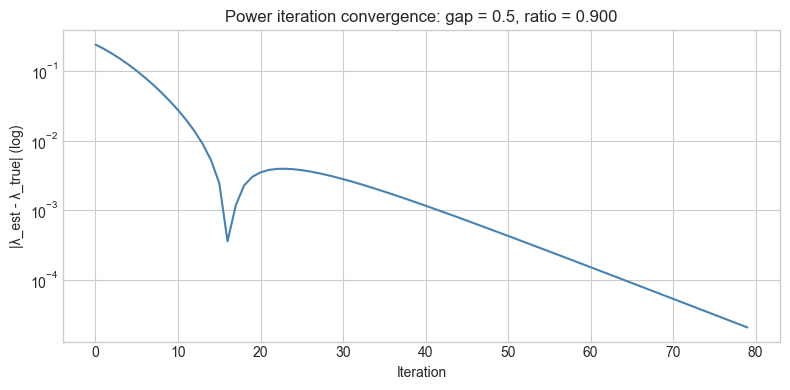

In [3]:
# --- Experiment 1: Convergence rate of power iteration ---
# Hypothesis: Convergence slows when eigenvalue gap is small
# Try changing: GAP (difference between the two largest eigenvalues)

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

GAP = 0.5  # try: 0.1, 0.5, 2.0, 0.01
LAM1 = 5.0
LAM2 = LAM1 - GAP

np.random.seed(3)
V = np.random.randn(2, 2)
A = V @ np.diag([LAM1, LAM2]) @ np.linalg.inv(V)

# Track error in eigenvalue estimate
v = np.random.randn(2); v /= np.linalg.norm(v)
errors = []
for _ in range(80):
    Av = A @ v
    lam_est = v @ Av
    errors.append(abs(lam_est - LAM1))
    v = Av / np.linalg.norm(Av)

plt.figure(figsize=(8, 4))
plt.semilogy(errors, 'steelblue')
plt.xlabel('Iteration')
plt.ylabel('|λ_est - λ_true| (log)')
plt.title(f'Power iteration convergence: gap = {GAP}, ratio = {LAM2/LAM1:.3f}')
plt.tight_layout()
plt.show()

In [4]:
# --- Experiment 2: Condition number and eigenvalue sensitivity ---
# Hypothesis: Adding small noise to a nearly-singular matrix causes large eigenvalue changes
# Try changing: EPSILON

import numpy as np

EPSILON = 1e-6  # try: 1e-1, 1e-3, 1e-6, 1e-10

# Nearly singular matrix
A = np.array([[1.0, 1.0],
              [1.0, 1.0 + EPSILON]])

eigs = np.linalg.eigvals(A)
cond = np.linalg.cond(A)
print(f"Epsilon = {EPSILON:.1e}")
print(f"Eigenvalues: {sorted(eigs, reverse=True)}")
print(f"Condition number: {cond:.2e}")
print(f"Smallest eigenvalue: {min(abs(eigs)):.2e}")

Epsilon = 1.0e-06
Eigenvalues: [np.float64(2.000000500000125), np.float64(4.999998750587764e-07)]
Condition number: 4.00e+06
Smallest eigenvalue: 5.00e-07


## 7. Exercises

**Easy 1.** Run `power_iteration` on the matrix [[4, 1], [2, 3]] and verify the result against `np.linalg.eig`. How many iterations does it take?

**Easy 2.** What is the Rayleigh quotient R(v) when v is the true eigenvector? Show algebraically and verify with code.

**Medium 1.** Implement **inverse iteration**: to find the eigenvalue closest to a target σ, run power iteration on (A - σI)⁻¹. Verify it converges to the eigenvalue nearest σ.

**Medium 2.** Modify `qr_algorithm` to use a **shift**: at each step, compute Aₖ - μI·Q·R and Aₖ₊₁ = RQ + μI where μ is the bottom-right entry of Aₖ. Compare convergence speed with and without the shift on a 4×4 matrix.

**Hard.** Implement **deflation**: after finding the dominant eigenvalue λ₁ and eigenvector v₁, subtract the rank-1 update A' = A - λ₁v₁v₁ᵀ/||v₁||². Show that A' has eigenvalue 0 where A had λ₁, and the same remaining eigenvalues. Use this to compute all eigenvalues of a 4×4 matrix sequentially.

## 8. Mini Project: Spectral Analysis of a Graph

Laplacian eigenvalues:
  λ0 = -0.0000
  λ1 = 0.0638
  λ2 = 3.0000
  λ3 = 3.0000
  λ4 = 3.0000
  λ5 = 3.1362


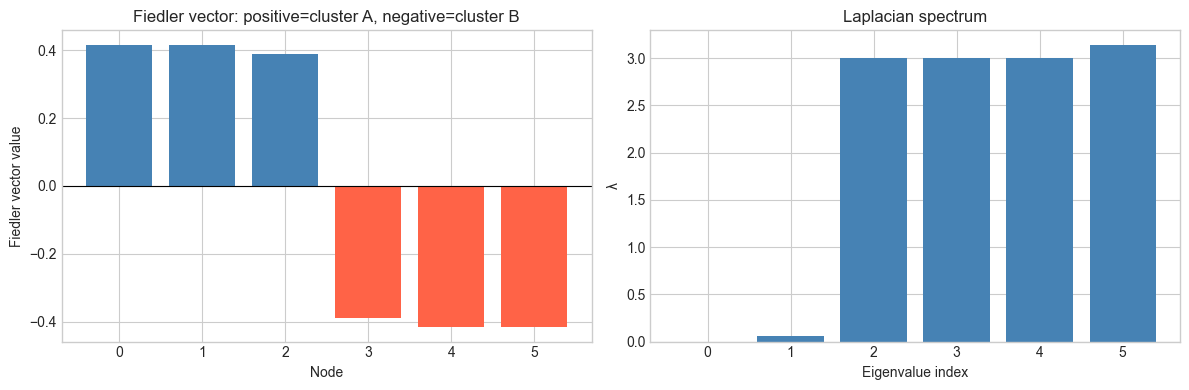


Fiedler value (λ1=0.0638): connectivity measure
Signs of Fiedler vector indicate cluster membership:
['+', '+', '+', '-', '-', '-']


In [5]:
# --- Mini Project: Eigenvalues of an adjacency matrix ---
# Problem: The eigenvalues of a graph's adjacency matrix encode its structure.
#          The largest eigenvalue relates to connectivity; the second-smallest
#          Laplacian eigenvalue reveals cluster structure.
# Task: Build a small graph, compute its Laplacian, find eigenvalues,
#       and use them to detect clusters.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Adjacency matrix: two clusters (nodes 0-2 and 3-5) with a weak bridge
n = 6
A_adj = np.zeros((n, n))

# Dense connections within clusters
for i in range(3):
    for j in range(i+1, 3):
        A_adj[i, j] = A_adj[j, i] = 1
for i in range(3, 6):
    for j in range(i+1, 6):
        A_adj[i, j] = A_adj[j, i] = 1

# Weak bridge between clusters
A_adj[2, 3] = A_adj[3, 2] = 0.1  # TODO: try 0, 0.5, 1.0

# Laplacian: L = D - A where D = degree matrix
D = np.diag(A_adj.sum(axis=1))
L = D - A_adj

eigvals, eigvecs = np.linalg.eigh(L)  # eigh for symmetric

print("Laplacian eigenvalues:")
for i, ev in enumerate(eigvals):
    print(f"  λ{i} = {ev:.4f}")

# The Fiedler vector: eigenvector of second-smallest eigenvalue
fiedler_vec = eigvecs[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(n), fiedler_vec, color=['steelblue' if f > 0 else 'tomato' for f in fiedler_vec])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Fiedler vector value')
axes[0].set_title('Fiedler vector: positive=cluster A, negative=cluster B')

axes[1].bar(range(n), eigvals, color='steelblue')
axes[1].set_xlabel('Eigenvalue index')
axes[1].set_ylabel('λ')
axes[1].set_title('Laplacian spectrum')

plt.tight_layout()
plt.show()
print(f"\nFiedler value (λ1={eigvals[1]:.4f}): connectivity measure")
print("Signs of Fiedler vector indicate cluster membership:")
print(['+' if f > 0 else '-' for f in fiedler_vec])

## 9. Chapter Summary & Connections

- For n > 4, eigenvalues cannot be computed algebraically — iterative numerical methods are required.
- Power iteration finds the dominant eigenpair; it converges at rate |λ₂/λ₁|ᵏ.
- The QR algorithm finds all eigenvalues by iteratively triangularizing the matrix via similarity transforms.
- Condition number determines eigenvalue sensitivity to matrix perturbations.
- Graph Laplacian eigenvalues encode connectivity structure — foundational to spectral clustering.

**Backward:** Power iteration was previewed in ch169's mini project. QR decomposition appeared in ch162 (Matrix Factorization).

**Forward:**
- ch172 (Diagonalization): using eigenvectors to decompose A = VΛV⁻¹
- ch173 (SVD): extends eigendecomposition to non-square matrices using singular vectors
- ch191 (Graph Embedding): spectral methods for embedding graphs in low-dimensional spaces

**Going deeper:** LAPACK's `dsyev` (symmetric) and `dgeev` (general) routines are what NumPy calls. They use the Francis double-shift QR algorithm for fast convergence.